# 🏠 House Price Prediction — End-to-End Pipeline

**Dataset** : `yasserh/housing-prices-dataset` (Kaggle — free, public dataset)  
**Goal**    : Predict the sale price of a house based on its features  
**Output**  : `model.pkl`, `scaler.pkl`, `label_encoders.pkl` downloaded to your machine

---
**How to run:**
1. Upload your `kaggle.json` when Cell 1 asks  
2. `Runtime → Run all`  
3. Model artifacts auto-download at the end  

**Sections**
1. Setup & Kaggle API  
2. Download Dataset  
3. Explore the Data  
4. Preprocess & Feature Engineering  
5. Train & Compare Models  
6. Evaluate Best Model  
7. Save & Download Model

## 1️⃣  Setup & Kaggle API

In [ ]:
# Install extra libraries
!pip install -q kaggle xgboost lightgbm

import os, warnings
warnings.filterwarnings('ignore')

# Upload kaggle.json
from google.colab import files
print('📁 Upload your kaggle.json API key...')
uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
# Get the content of the uploaded file, and save it as 'kaggle.json'
# because the Kaggle CLI expects this specific filename.
uploaded_content = next(iter(uploaded.values()))
with open('/root/.config/kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded_content)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# Explicitly set the KAGGLE_CONFIG_DIR environment variable
# to ensure the Kaggle CLI looks in the correct path.
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.config/kaggle'

print('✅ Kaggle API key ready!')

📁 Upload your kaggle.json API key...


Saving kaggle (2).json to kaggle (2).json
✅ Kaggle API key ready!


## 2️⃣  Download Dataset

In [ ]:
import zipfile

os.makedirs('/content/data', exist_ok=True)

print('⬇️  Downloading yasserh/housing-prices-dataset ...')
!kaggle datasets download -d yasserh/housing-prices-dataset -p /content/data --quiet

# Unzip
for fname in os.listdir('/content/data'):
    if fname.endswith('.zip'):
        with zipfile.ZipFile(f'/content/data/{fname}') as z:
            z.extractall('/content/data/')
        print(f'✅ Unzipped {fname}')

# Find the CSV
csv_path = None
for root, _, fnames in os.walk('/content/data'):
    for f in fnames:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            print(f'✅ Dataset found: {csv_path}')
            break

if csv_path is None:
    raise FileNotFoundError('CSV not found — check listing below:')
    !ls /content/data

⬇️  Downloading yasserh/housing-prices-dataset ...
Dataset URL: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset
License(s): CC0-1.0
✅ Unzipped housing-prices-dataset.zip
✅ Dataset found: /content/data/Housing.csv


## 3️⃣  Explore the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 13})
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [ ]:
df = pd.read_csv("/content/Housing.csv")

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Shape   : (545, 13)
Columns : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
print('=== Data Types & Missing Values ===')
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'missing' : df.isnull().sum(),
    'missing%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

=== Data Types & Missing Values ===
                   dtype  missing  missing%
price              int64        0       0.0
area               int64        0       0.0
bedrooms           int64        0       0.0
bathrooms          int64        0       0.0
stories            int64        0       0.0
mainroad          object        0       0.0
guestroom         object        0       0.0
basement          object        0       0.0
hotwaterheating   object        0       0.0
airconditioning   object        0       0.0
parking            int64        0       0.0
prefarea          object        0       0.0
furnishingstatus  object        0       0.0

Total missing cells: 0


In [ ]:
print('=== Statistical Summary ===')
df.describe(include='all').T

=== Statistical Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Target column detected: price


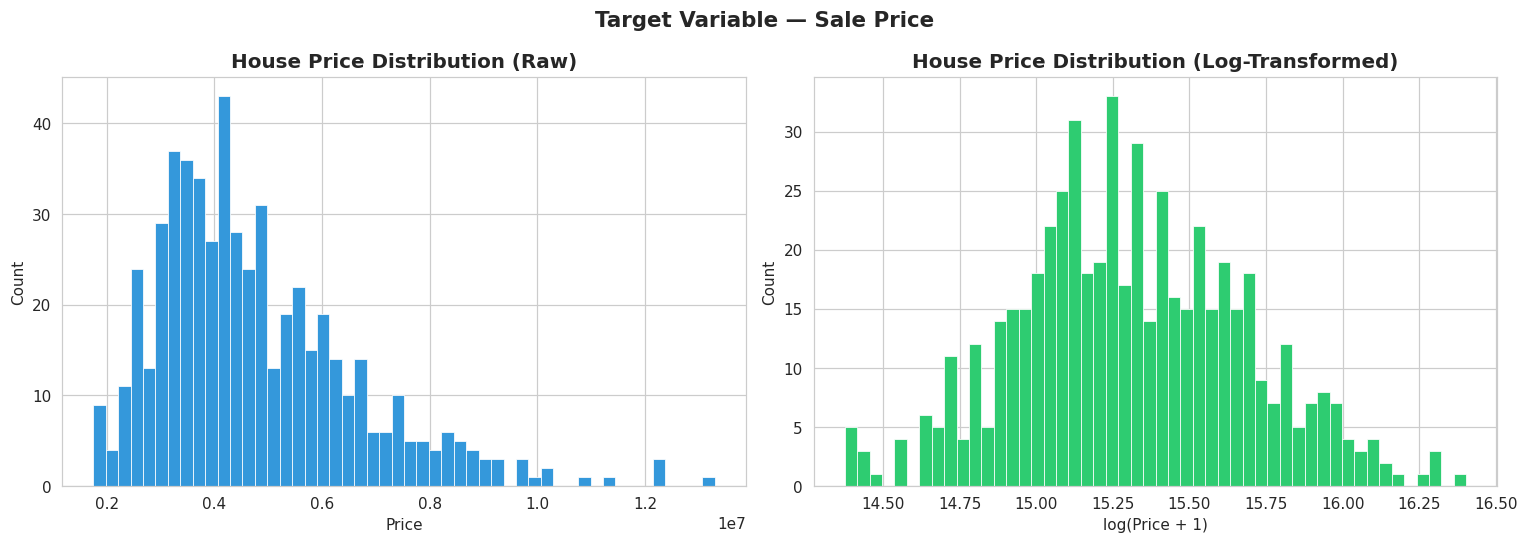

Mean price   : $4,766,729
Median price : $4,340,000
Std dev      : $1,870,440


In [ ]:
# Target column — auto-detect
price_candidates = [c for c in df.columns if 'price' in c.lower() or 'saleprice' in c.lower()]
target_col = price_candidates[0] if price_candidates else df.columns[-1]
print(f'Target column detected: {target_col}')

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[target_col], bins=50, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_title('House Price Distribution (Raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df[target_col]), bins=50, color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[1].set_title('House Price Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable — Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean price   : ${df[target_col].mean():,.0f}')
print(f'Median price : ${df[target_col].median():,.0f}')
print(f'Std dev      : ${df[target_col].std():,.0f}')

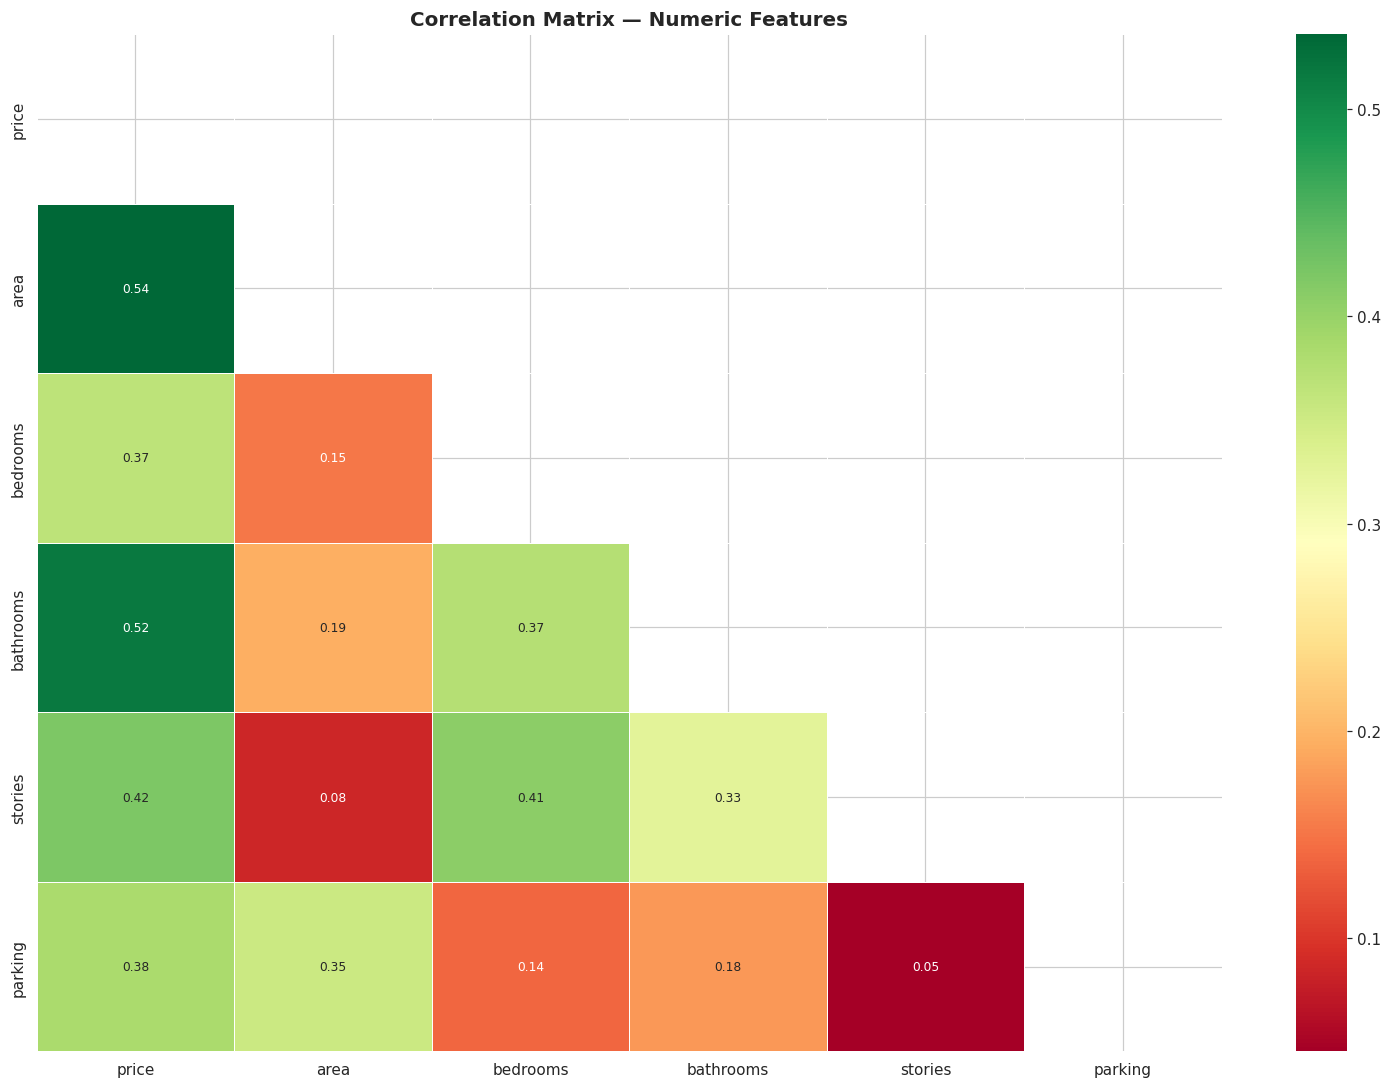

In [ ]:
# Correlation heatmap for numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

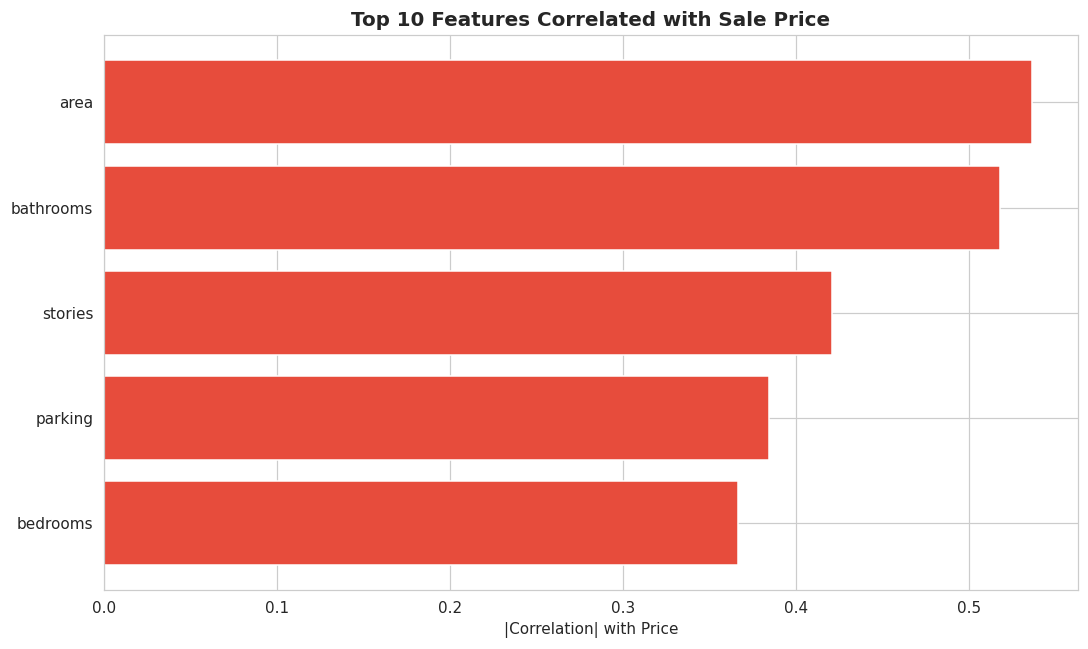

In [ ]:
# Top correlated features with target
top_corr = corr[target_col].abs().sort_values(ascending=False).drop(target_col).head(10)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr[target_col].loc[top_corr.index]]
plt.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
plt.xlabel('|Correlation| with Price')
plt.title('Top 10 Features Correlated with Sale Price', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

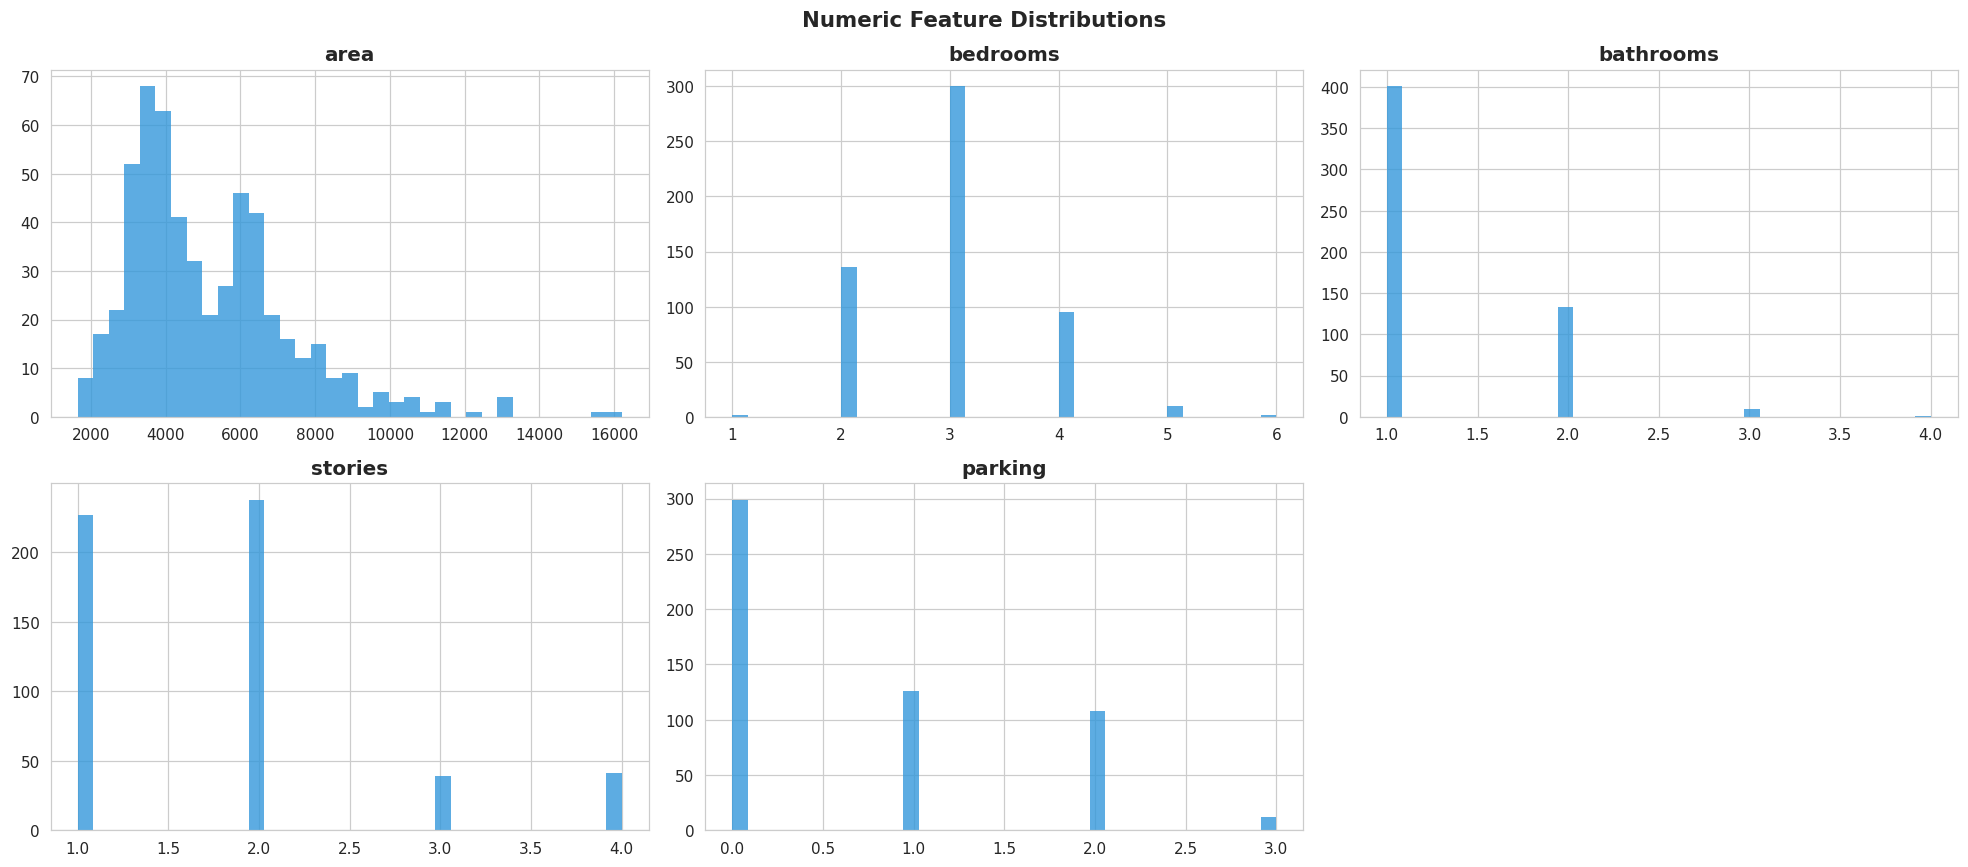

In [ ]:
# Numeric feature distributions
num_features = [c for c in num_cols if c != target_col]
n = min(len(num_features), 12)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features[:n]):
    axes[i].hist(df[col].dropna(), bins=35, color='#3498db', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4️⃣  Preprocess & Feature Engineering

In [ ]:
df_clean = df.copy()

# Drop ID-like columns
id_cols = [c for c in df_clean.columns if 'id' in c.lower()]
if id_cols:
    df_clean.drop(columns=id_cols, inplace=True)
    print(f'Dropped ID columns: {id_cols}')

# Drop columns with > 50% missing
high_missing = [c for c in df_clean.columns if df_clean[c].isnull().mean() > 0.5]
if high_missing:
    df_clean.drop(columns=high_missing, inplace=True)
    print(f'Dropped high-missing columns: {high_missing}')

# Encode categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded  {col}  →  {list(le.classes_[:5])}...')

# Fill missing values
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        fill_val = df_clean[col].median()
        df_clean[col].fillna(fill_val, inplace=True)
        print(f'Imputed  {col}  with median={fill_val:.2f}')

print(f'\n✅ Preprocessing done. Missing: {df_clean.isnull().sum().sum()}')
print(f'Shape after cleaning: {df_clean.shape}')

Encoded  mainroad  →  ['no', 'yes']...
Encoded  guestroom  →  ['no', 'yes']...
Encoded  basement  →  ['no', 'yes']...
Encoded  hotwaterheating  →  ['no', 'yes']...
Encoded  airconditioning  →  ['no', 'yes']...
Encoded  prefarea  →  ['no', 'yes']...
Encoded  furnishingstatus  →  ['furnished', 'semi-furnished', 'unfurnished']...

✅ Preprocessing done. Missing: 0
Shape after cleaning: (545, 13)


In [ ]:
df_feat = df_clean.copy()

# --- Feature Engineering ---
col_lower = {c.lower(): c for c in df_feat.columns}

# Price per sqft
area_col  = col_lower.get('area') or col_lower.get('grlivarea') or col_lower.get('sqft')
bed_col   = col_lower.get('bedrooms') or col_lower.get('bedroomabvgr')
bath_col  = col_lower.get('bathrooms') or col_lower.get('fullbath')
yr_col    = col_lower.get('yearbuilt') or col_lower.get('year_built')
garage_col= col_lower.get('garagearea') or col_lower.get('parking')
stories_col = col_lower.get('stories') or col_lower.get('floors')

if area_col:
    df_feat['PricePerSqft_proxy'] = df_feat[area_col] / (df_feat[area_col].mean())
    print(f'Created: PricePerSqft_proxy from {area_col}')

if bed_col and bath_col:
    df_feat['BedBathRatio'] = df_feat[bed_col] / (df_feat[bath_col] + 1)
    print(f'Created: BedBathRatio')

if yr_col:
    df_feat['HouseAge'] = 2024 - df_feat[yr_col]
    df_feat['IsNew']    = (df_feat['HouseAge'] <= 5).astype(int)
    print(f'Created: HouseAge, IsNew from {yr_col}')

if area_col and bed_col:
    df_feat['AreaPerBedroom'] = df_feat[area_col] / (df_feat[bed_col] + 1)
    print(f'Created: AreaPerBedroom')

if garage_col:
    df_feat['HasGarage'] = (df_feat[garage_col] > 0).astype(int)
    print(f'Created: HasGarage')

if stories_col:
    df_feat['IsMultiStorey'] = (df_feat[stories_col] > 1).astype(int)
    print(f'Created: IsMultiStorey')

print(f'\n✅ Feature engineering done. Total features: {df_feat.shape[1] - 1}')

Created: PricePerSqft_proxy from area
Created: BedBathRatio
Created: AreaPerBedroom
Created: HasGarage
Created: IsMultiStorey

✅ Feature engineering done. Total features: 17


## 5️⃣  Train & Compare Models

In [ ]:
X = df_feat.drop(target_col, axis=1)
y = df_feat[target_col]

# Log-transform target for better regression
y_log = np.log1p(y)

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape}   Test : {X_test.shape}')
print(f'Target range (log) : {y_train.min():.2f} – {y_train.max():.2f}')

Train : (436, 17)   Test : (109, 17)
Target range (log) : 14.38 – 16.32


In [ ]:
# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('✅ Scaling done.')

✅ Scaling done.


In [ ]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=10, random_state=42),
    'Random Forest'    : RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=3,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    'XGBoost'          : XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, random_state=42,
        n_jobs=-1, verbosity=0
    ),
    'LightGBM'         : LGBMRegressor(
        n_estimators=400, max_depth=8, learning_rate=0.05,
        num_leaves=63, min_child_samples=20,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

def evaluate_reg(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr)
    yp_log = model.predict(Xte)
    # Convert back from log scale
    yp  = np.expm1(yp_log)
    ytr_orig = np.expm1(yte)
    mae  = mean_absolute_error(ytr_orig, yp)
    rmse = np.sqrt(mean_squared_error(ytr_orig, yp))
    r2   = r2_score(yte, yp_log)
    return {
        'model'   : model,
        'name'    : name,
        'mae'     : mae,
        'rmse'    : rmse,
        'r2'      : r2,
        'y_pred'  : yp,
        'y_pred_log': yp_log
    }

results = {}
for name, model in models.items():
    use_scaled = name in ['Linear Regression', 'Ridge Regression']
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    print(f'  Training {name} ...', end=' ', flush=True)
    results[name] = evaluate_reg(model, Xtr, y_train, Xte, y_test, name)
    print(f'R² = {results[name]["r2"]:.4f}  |  MAE = ${results[name]["mae"]:,.0f}')

print('\n✅ All models trained!')

  Training Linear Regression ... R² = 0.6539  |  MAE = $994,514
  Training Ridge Regression ... R² = 0.6545  |  MAE = $989,946
  Training Random Forest ... R² = 0.6274  |  MAE = $1,036,162
  Training XGBoost ... R² = 0.6618  |  MAE = $972,133
  Training LightGBM ... R² = 0.6440  |  MAE = $999,177

✅ All models trained!


In [ ]:
# Cross Validation of the model
from sklearn.model_selection import KFold, cross_val_score

# Get the best model and its name
best_model_instance = best['model']
best_model_name = best['name']

print(f'Performing cross-validation for {best_model_name}...')

# Determine whether to use scaled data based on the best model type
use_scaled_data = best_model_name in ['Linear Regression', 'Ridge Regression']
X_data_for_cv = X_train_sc if use_scaled_data else X_train

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model_instance, X_data_for_cv, y_train, cv=kf, scoring='r2', n_jobs=-1)

print(f'Cross-validation R² scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean():.4f}')
print(f'Std CV R²: {cv_scores.std():.4f}')

Performing cross-validation for XGBoost...
Cross-validation R² scores: [0.57704281 0.49468281 0.6102203  0.7170267  0.56488968]
Mean CV R²: 0.5928
Std CV R²: 0.0726



📊 Model Comparison (sorted by R²):
            Model     R²   MAE ($)  RMSE ($)
          XGBoost 0.6618  972133.0 1360434.0
 Ridge Regression 0.6545  989946.0 1341479.0
Linear Regression 0.6539  994514.0 1342985.0
         LightGBM 0.6440  999177.0 1393158.0
    Random Forest 0.6274 1036162.0 1451924.0


/tmp/ipykernel_4058/3282914962.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_comp['Model'], rotation=20, ha='right')
/tmp/ipykernel_4058/3282914962.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_comp['Model'], rotation=20, ha='right')
/tmp/ipykernel_4058/3282914962.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_comp['Model'], rotation=20, ha='right')


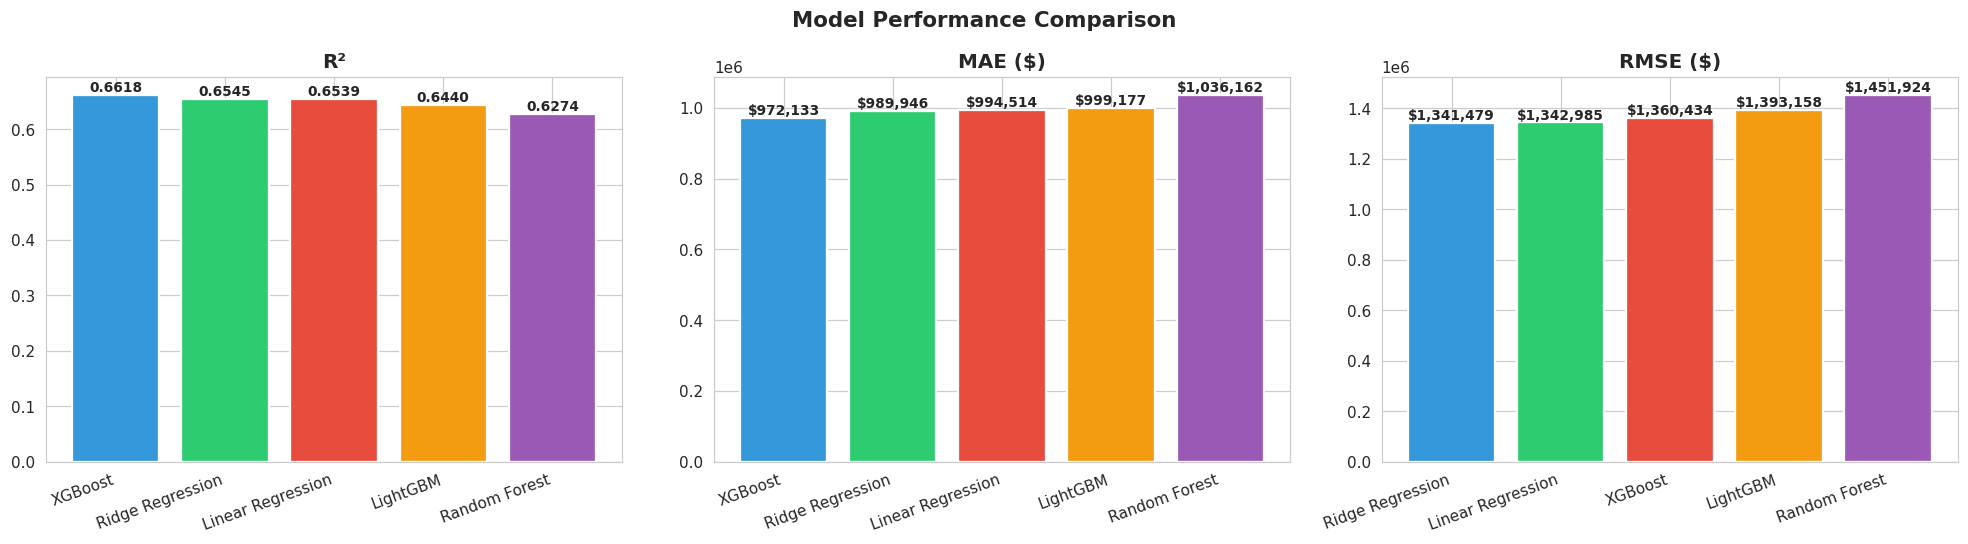

In [ ]:
# Comparison table
comp = pd.DataFrame([
    {
        'Model'  : r['name'],
        'R²'     : round(r['r2'],   4),
        'MAE ($)': round(r['mae'],  0),
        'RMSE ($)': round(r['rmse'], 0)
    }
    for r in results.values()
]).sort_values('R²', ascending=False).reset_index(drop=True)

print('\n📊 Model Comparison (sorted by R²):')
print(comp.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for ax, (metric, ascending) in zip(axes, [('R²', False), ('MAE ($)', True), ('RMSE ($)', True)]):
    sorted_comp = comp.sort_values(metric, ascending=ascending)
    bars = ax.bar(sorted_comp['Model'], sorted_comp[metric],
                  color=palette[:len(sorted_comp)], edgecolor='white', linewidth=1.5)
    ax.set_title(metric)
    ax.set_xticklabels(sorted_comp['Model'], rotation=20, ha='right')
    for bar in bars:
        val = bar.get_height()
        label = f'{val:.4f}' if metric == 'R²' else f'${val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, val * 1.01,
                label, ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6️⃣  Evaluate Best Model

In [ ]:
best_name = comp.iloc[0]['Model']
best = results[best_name]

print(f'🏆 Best Model : {best_name}')
print(f'   R²         : {best["r2"]:.4f}')
print(f'   MAE        : ${best["mae"]:,.0f}')
print(f'   RMSE       : ${best["rmse"]:,.0f}')

🏆 Best Model : XGBoost
   R²         : 0.6618
   MAE        : $972,133
   RMSE       : $1,360,434


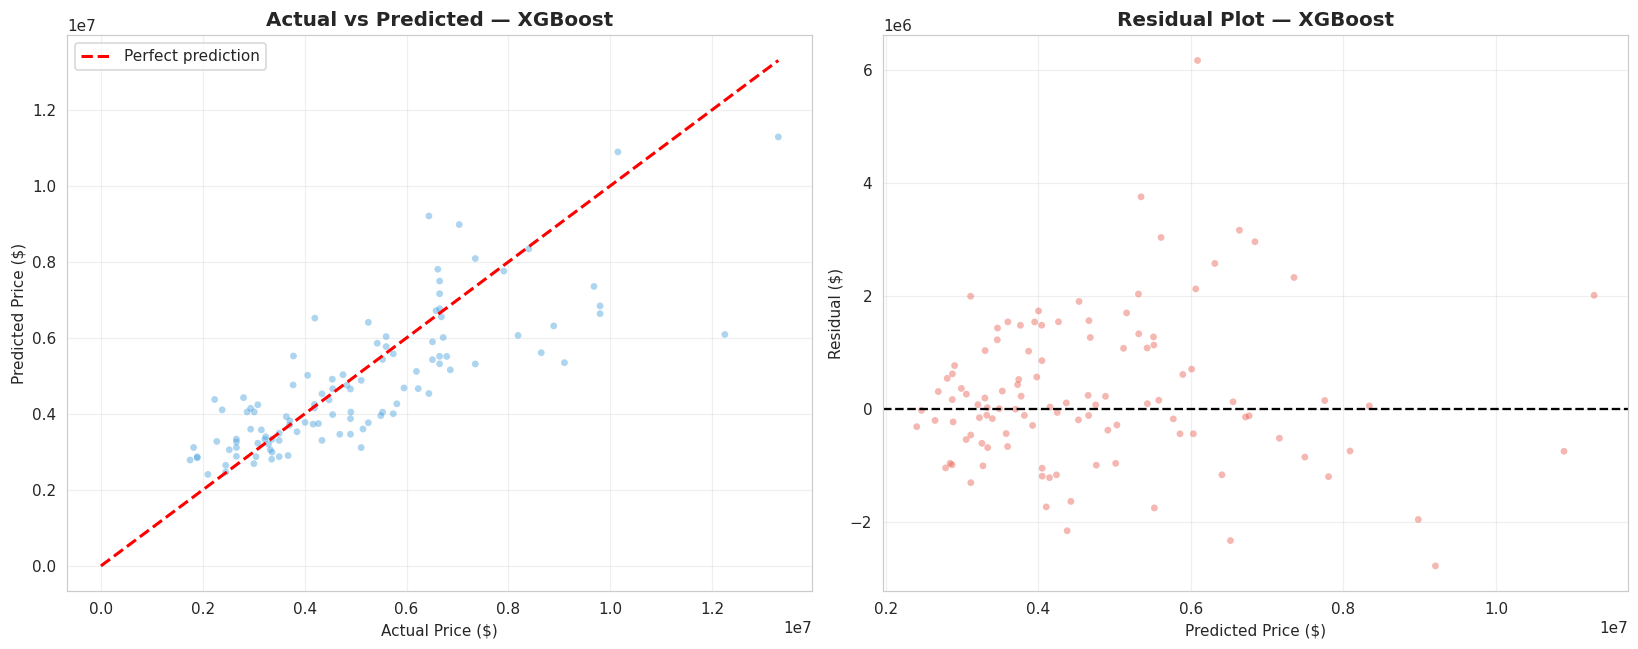


Mean Residual : $265,862
Std  Residual : $1,340,366


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted
y_actual = np.expm1(y_test)
y_pred   = best['y_pred']

axes[0].scatter(y_actual, y_pred, alpha=0.4, color='#3498db', edgecolors='none', s=20)
max_val = max(y_actual.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_actual - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='#e74c3c', edgecolors='none', s=20)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title(f'Residual Plot — {best_name}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nMean Residual : ${residuals.mean():,.0f}')
print(f'Std  Residual : ${residuals.std():,.0f}')

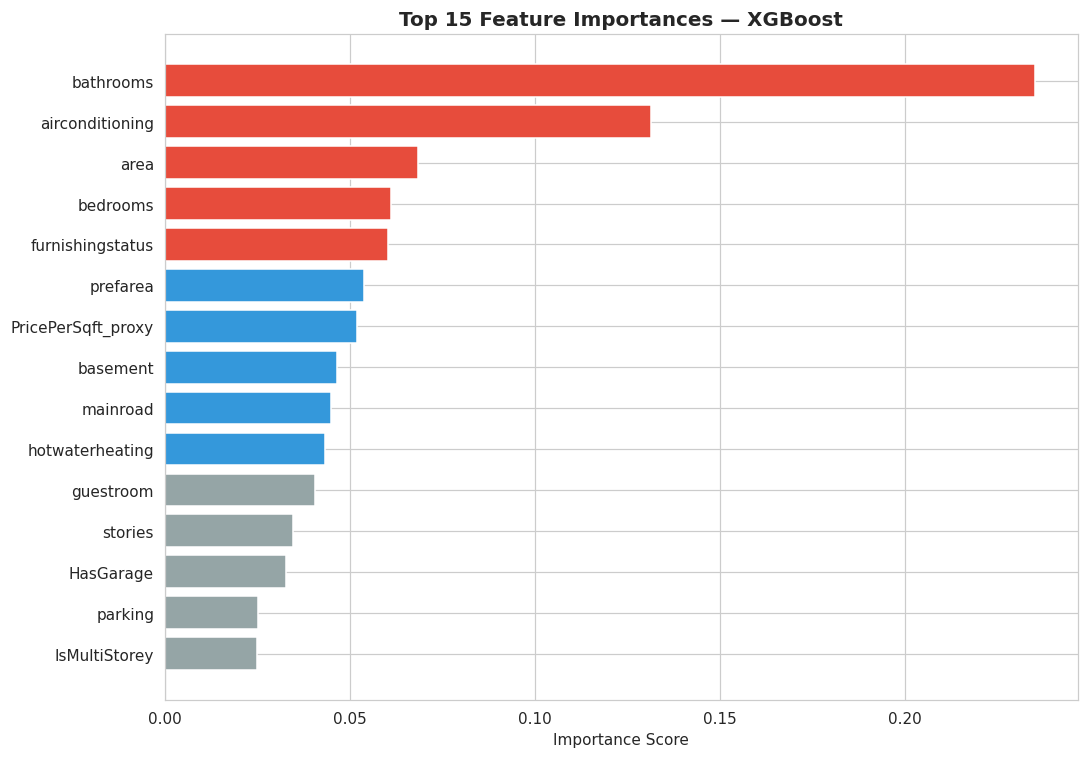

In [ ]:
# Feature Importance
if best_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    imp = pd.DataFrame({'Feature': feature_names,
                        'Importance': best['model'].feature_importances_})
    imp = imp.sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    colors_fi = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6'
                 for i in range(len(imp))]
    plt.barh(imp['Feature'], imp['Importance'], color=colors_fi, edgecolor='white')
    plt.xlabel('Importance Score')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7️⃣  Save & Download Model

In [ ]:
import joblib
import json
import os

os.makedirs('/content/output', exist_ok=True)

# Save artifacts
joblib.dump(best['model'],  '/content/output/model.pkl')
joblib.dump(scaler,         '/content/output/scaler.pkl')
joblib.dump(label_encoders, '/content/output/label_encoders.pkl')

meta = {
    'model_type'   : best_name,
    'r2'           : round(best['r2'],   4),
    'mae'          : round(best['mae'],  2),
    'rmse'         : round(best['rmse'], 2),
    'feature_names': feature_names,
    'target_col'   : target_col,
    'log_transform': True,
    'train_samples': len(X_train),
    'test_samples' : len(X_test)
}
with open('/content/output/metrics.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ All artifacts saved!')
print(f'   model.pkl          — {best_name}')
print(f'   scaler.pkl         — StandardScaler')
print(f'   label_encoders.pkl — {len(label_encoders)} encoders')
print(f'   metrics.json       — R²={best["r2"]:.4f}, MAE=${best["mae"]:,.0f}')

✅ All artifacts saved!
   model.pkl          — XGBoost
   scaler.pkl         — StandardScaler
   label_encoders.pkl — 7 encoders
   metrics.json       — R²=0.6618, MAE=$972,133


In [ ]:
# Download all artifacts
from google.colab import files
for fname in ['model.pkl', 'scaler.pkl', 'label_encoders.pkl', 'metrics.json']:
    files.download(f'/content/output/{fname}')
    print(f'⬇️  Downloaded {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloaded label_encoders.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded metrics.json


In [ ]:
print('📊 Model Comparison (sorted by R²):')
print(comp.to_string(index=False))

📊 Model Comparison (sorted by R²):
            Model     R²   MAE ($)  RMSE ($)
          XGBoost 0.6618  972133.0 1360434.0
 Ridge Regression 0.6545  989946.0 1341479.0
Linear Regression 0.6539  994514.0 1342985.0
         LightGBM 0.6440  999177.0 1393158.0
    Random Forest 0.6274 1036162.0 1451924.0


In [ ]:
df.info()

print("----------")

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
----------


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000
